# Tutorial: Mock Interferometer Imaging

This tutorial uses `fast_interferometer` to simulate dirty maps from a mock antenna array.

The sky map must have shape `(y_npix, x_npix)` — the same dimensions passed to the instrument constructor. UV coverage is gridded from the field of view (`theta_x`, `theta_y`) and baseline geometry at the observing frequency.


## Imports

In [89]:
import numpy as np
import matplotlib.pyplot as plt
from astropy import units
from scipy import stats

#import log norm plotting
from matplotlib.colors import LogNorm
from limstat.fast_interferometer import fast_interferometer

np.random.seed(42)

# autoreload the fast_interferometer module
%load_ext autoreload
%autoreload 2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Observation setup

We use 150 MHz and a square field of view. Set `npix` for both the instrument grid and the sky map (they must match).


In [49]:
freq = 150 * units.MHz
wavelength = (3e8 * units.m / units.s / freq.to(units.Hz)).to(units.m)

fov = 10 * units.deg
theta = fov
npix = 96

T_sys = 200 * units.K
t_obs = 1000 * units.hr
bandwidth = 8 * units.MHz

print(f'Frequency: {freq}')
print(f'Wavelength: {wavelength:.3f}')
print(f'Field of view: {fov}')
print(f'Image / UV grid: {npix} x {npix} pixels')


Frequency: 150.0 MHz
Wavelength: 2.000 m
Field of view: 10.0 deg
Image / UV grid: 96 x 96 pixels


## Mock true sky

Shape must be `(y_npix, x_npix)`.


In [50]:
yy, xx = np.mgrid[0:npix, 0:npix]
cy, cx = npix // 2, npix // 2

sigma = npix / 8
smooth = 5.0 * np.exp(-((xx - cx) ** 2 + (yy - cy) ** 2) / (2 * sigma ** 2))

point = np.zeros_like(smooth)
point[cy + 12, cx - 15] = 80.0

true_sky_mK = point
true_sky = (true_sky_mK * units.mK).to(units.K).value

assert true_sky.shape == (npix, npix)
print(f'True sky shape: {true_sky.shape}')


True sky shape: (96, 96)


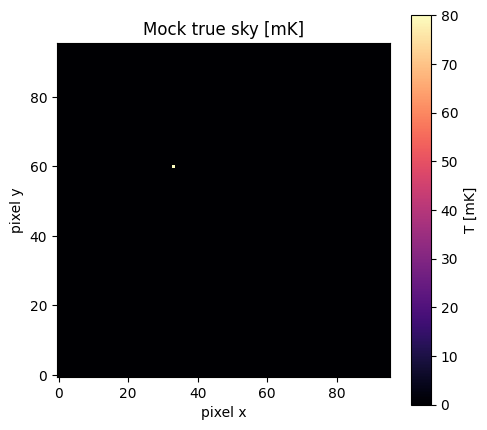

In [51]:
fig, ax = plt.subplots(figsize=(5, 4.5))
im = ax.imshow(true_sky_mK, origin='lower', cmap='magma')
ax.set_title('Mock true sky [mK]')
ax.set_xlabel('pixel x')
ax.set_ylabel('pixel y')
plt.colorbar(im, ax=ax, label='T [mK]')
plt.tight_layout()


## Mock antenna array

Two helper functions build antenna coordinates (astropy `units.m`):

- **`mock_grid`** — perturbed regular grid inside the aperture
- **`mock_random`** — uniform random positions inside the aperture

Set `ARRAY_LAYOUT` to `'grid'` or `'random'` to choose which layout to use.


In [169]:
def mock_grid(n_ants=12, aperture_m=30.0, seed=42):
    """Antennas on a perturbed regular grid inside a square aperture."""
    rng = np.random.default_rng(seed)
    grid_side = int(np.ceil(np.sqrt(n_ants)))
    xs = np.linspace(-aperture_m / 2, aperture_m / 2, grid_side)
    ys = np.linspace(-aperture_m / 2, aperture_m / 2, grid_side)
    xx, yy = np.meshgrid(xs, ys)
    coords = np.column_stack([xx.ravel(), yy.ravel()])[:n_ants]
    coords += rng.normal(0, 0.3, coords.shape)
    return coords * units.m


def mock_random(n_ants=12, aperture_m=30.0, seed=42):
    """Antennas placed at random positions inside a square aperture."""
    rng = np.random.default_rng(seed)
    coords = rng.uniform(-aperture_m / 2, aperture_m / 2, size=(n_ants, 2))
    return coords * units.m


ARRAY_LAYOUT = 'random'  # 'grid' or 'random'

n_ants = 50
aperture_m = 300.0
seed = 42

if ARRAY_LAYOUT == 'grid':
    ant_locs = mock_grid(n_ants=n_ants, aperture_m=aperture_m, seed=seed)
elif ARRAY_LAYOUT == 'random':
    ant_locs = mock_random(n_ants=n_ants, aperture_m=aperture_m, seed=seed)
else:
    raise ValueError("ARRAY_LAYOUT must be 'grid' or 'random'")

print(f'Layout: {ARRAY_LAYOUT}')
print(f'{ant_locs.shape[0]} antennas, aperture = {aperture_m} m')


Layout: random
50 antennas, aperture = 300.0 m


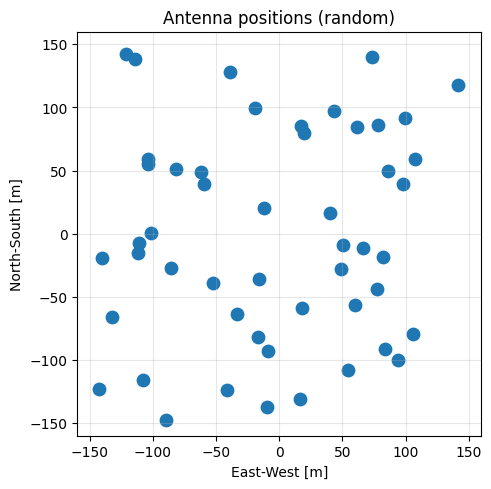

In [170]:
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(
    ant_locs[:, 0].to(units.m).value,
    ant_locs[:, 1].to(units.m).value,
    s=80,
    c='C0',
)

ax.set_xlim(-aperture_m / 2-10, aperture_m / 2+10)
ax.set_ylim(-aperture_m / 2-10, aperture_m / 2+10)
ax.set_xlabel('East-West [m]')
ax.set_ylabel('North-South [m]')
ax.set_title(f'Antenna positions ({ARRAY_LAYOUT})')
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
plt.tight_layout()


## Build the instrument and baselines


In [171]:
instrument = fast_interferometer(
    ant_locs=ant_locs,
    theta_x=theta,
    theta_y=theta,
    x_npix=npix,
    y_npix=npix,
    T_sys=T_sys,
    t_obs=t_obs,
    bandwidth=bandwidth,
)

bls = instrument.get_bls(freq)
print(f'{bls.shape[0]} unique baseline vectors (including -u,-v pairs)')


2450 unique baseline vectors (including -u,-v pairs)


## UV coverage

`get_uvmap` grids baselines onto a UV lattice set by the FOV and `x_npix` / `y_npix`.


In [172]:
uv_map_halfwave = instrument.get_uvmap_halfwave(freq)

In [173]:
u,v,l,m,dl,dm = instrument.sky_uv_coords()

In [174]:
sky_fft = instrument.sky_fft_to_uv(true_sky)
V_hw, uv_map = instrument.interp_sky_fft_to_halfwave(true_sky, freq)


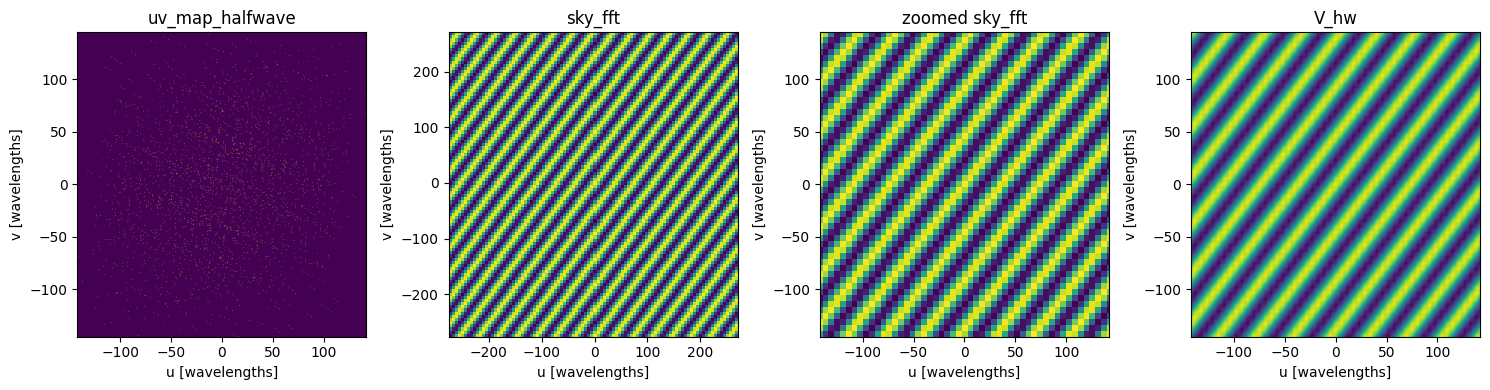

In [180]:
# plot 1 x 4 figure of uv_map_halfwave, sky_fft, zoomed sky_fft, V_hw,
fig, axes = plt.subplots(1, 4, figsize=(15, 4))

axes[0].imshow(uv_map_halfwave, origin='lower', extent = [instrument.u_grid[0],instrument.u_grid[-1],instrument.v_grid[0],instrument.v_grid[-1]], aspect='auto')
axes[0].set_xlabel('u [wavelengths]')
axes[0].set_ylabel('v [wavelengths]')
axes[0].set_title('uv_map_halfwave')

axes[1].imshow(sky_fft.real, origin='lower', extent = [u[0],u[-1],v[0],v[-1]], aspect='auto')
axes[1].set_xlabel('u [wavelengths]')
axes[1].set_ylabel('v [wavelengths]')
axes[1].set_title('sky_fft')

axes[2].imshow(sky_fft.real, origin='lower', extent = [u[0],u[-1],v[0],v[-1]], aspect='auto')
axes[2].set_xlim(instrument.u_grid[0],instrument.u_grid[-1])
axes[2].set_ylim(instrument.v_grid[0],instrument.v_grid[-1])
axes[2].set_xlabel('u [wavelengths]')
axes[2].set_ylabel('v [wavelengths]')
axes[2].set_title('zoomed sky_fft') 

axes[3].imshow(V_hw.real, origin='lower', extent = [instrument.u_grid[0],instrument.u_grid[-1],instrument.v_grid[0],instrument.v_grid[-1]], aspect='auto')
axes[3].set_xlabel('u [wavelengths]')
axes[3].set_ylabel('v [wavelengths]')
axes[3].set_title('V_hw')


plt.tight_layout()




In [177]:
obs_map = instrument.get_dirty_map(true_sky, freq, noise=False)

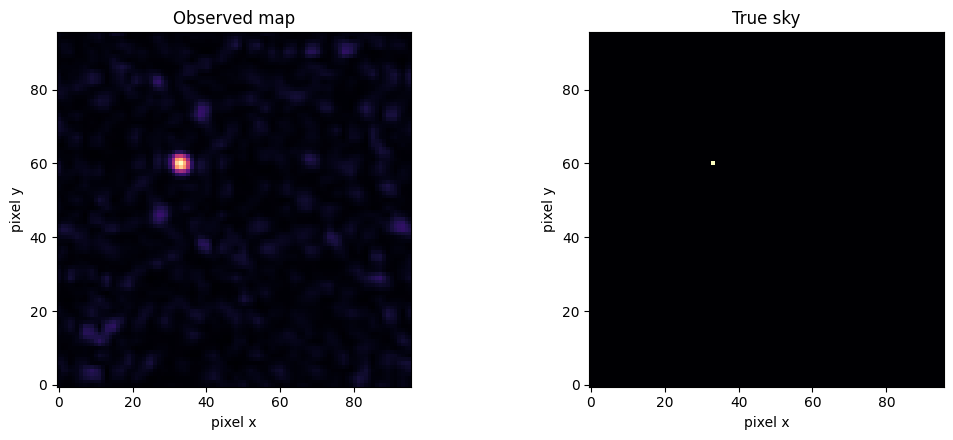

In [178]:
#side by side of obs_map and true_sky

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

axes[0].imshow(obs_map, origin='lower', cmap='magma')
axes[0].set_title('Observed map')
axes[0].set_xlabel('pixel x')
axes[0].set_ylabel('pixel y')

axes[1].imshow(true_sky, origin='lower', cmap='magma')
axes[1].set_title('True sky')
axes[1].set_xlabel('pixel x')
axes[1].set_ylabel('pixel y')

plt.tight_layout()

## Point spread function

`get_psf` Fourier-transforms the UV coverage mask.


In [121]:
psf = instrument.get_psf(freq)
print(f'PSF shape: {psf.shape}')


AttributeError: 'fast_interferometer' object has no attribute 'get_uvmap'

NameError: name 'psf' is not defined

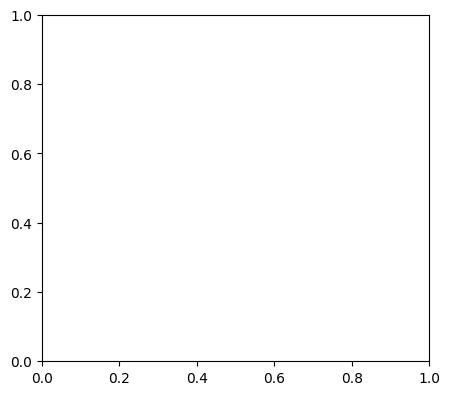

In [80]:
fig, ax = plt.subplots(figsize=(5, 4.5))
im = ax.imshow(psf.real, origin='lower', cmap='viridis')
ax.set_title('Instrument PSF (dirty beam)')
ax.set_xlabel('pixel x')
ax.set_ylabel('pixel y')
plt.colorbar(im, ax=ax)
plt.tight_layout()


## Noiseless dirty map

`get_dirty_map` FFTs the sky, multiplies by the UV coverage, and inverse-transforms.


In [44]:
dirty_noiseless = instrument.get_dirty_map(true_sky, freq, noise=False)

assert dirty_noiseless.shape == true_sky.shape
print(f'Dirty map shape: {dirty_noiseless.shape}')


Dirty map shape: (96, 96)


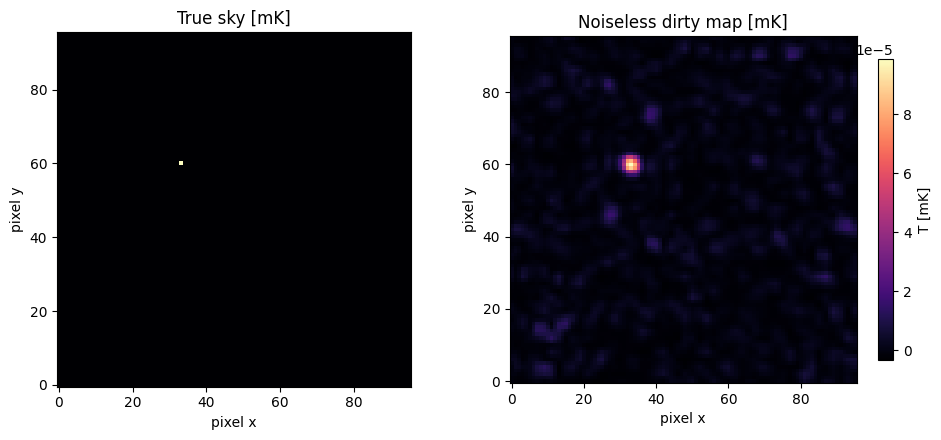

In [45]:

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))

axes[0].imshow(true_sky_mK, origin='lower', cmap='magma')
axes[0].set_title('True sky [mK]')

im1 = axes[1].imshow(dirty_noiseless, origin='lower', cmap='magma')
axes[1].set_title('Noiseless dirty map [mK]')

for ax in axes:
    ax.set_xlabel('pixel x')
    ax.set_ylabel('pixel y')

plt.colorbar(im1, label='T [mK]', shrink=0.85)
plt.tight_layout()


## Dirty map with noise

Pass `noise=True` for thermal noise in the UV plane. `get_noise_map` returns a noise-only image realization.


In [46]:
dirty_noisy = instrument.get_dirty_map(
    true_sky, freq, noise=True, redundancy=True,
)
noise_map = instrument.get_noise_map(freq, redundancy=True)

print(f'Per-visibility noise scale (approx): {instrument.compute_noise():.3e} K')


/Users/hannahfronenberg/Documents/Code/LIMstat/src/limstat/fast_interferometer.py:326: RuntimeWarning: divide by zero encountered in divide
  a = np.random.normal(0, redundant_noise, (npix_0, npix_1))


AttributeError: 'fast_interferometer' object has no attribute 'get_uvmap'

NameError: name 'noise_map' is not defined

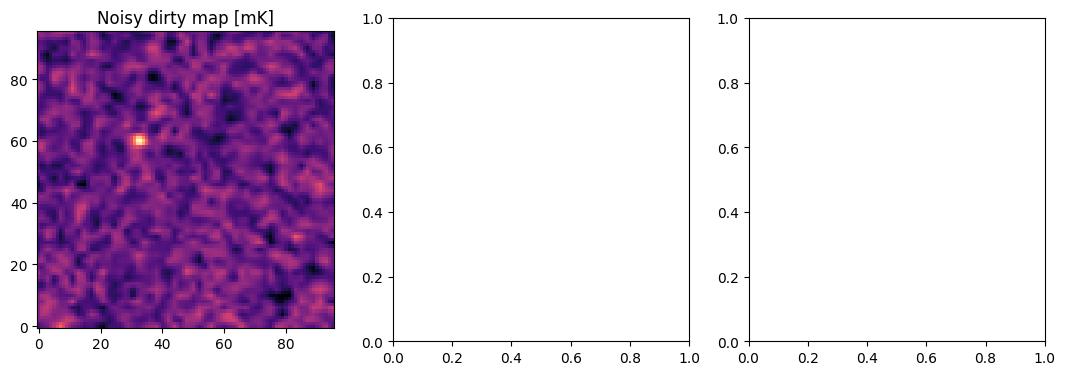

In [47]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))

im0 = axes[0].imshow(dirty_noisy * 1e3, origin='lower', cmap='magma')
axes[0].set_title('Noisy dirty map [mK]')

im1 = axes[1].imshow(noise_map * 1e3, origin='lower', cmap='coolwarm')
axes[1].set_title('Noise map [mK]')

residual = dirty_noisy - dirty_noiseless
im2 = axes[2].imshow(residual * 1e3, origin='lower', cmap='coolwarm')
axes[2].set_title('Noisy - noiseless [mK]')

for ax in axes:
    ax.set_xlabel('pixel x')
    ax.set_ylabel('pixel y')

plt.colorbar(im2, shrink=0.85)
plt.tight_layout()


## Summary

| Step | Method |
|------|--------|
| Baselines | `get_bls()` |
| UV coverage | `get_uvmap(freq)` |
| PSF | `get_psf(freq)` |
| Dirty map | `get_dirty_map(sky_map, freq, noise=False)` |
| Noise map | `get_noise_map(freq)` |

**Requirements:** `sky_map.shape == (y_npix, x_npix)`. Set `T_sys`, `t_obs`, and `bandwidth` before using noise.
